# Import the Python Modules

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data into data frames

In [3]:
df = pd.read_csv('StudentPerformanceFactors.csv')

In [ ]:
df.head()

After loading the data into a data frame, we can now explore the data frame before doing any analysis  

In [ ]:
parental_Exam_mean = df.groupby(['Parental_Education_Level', 'Family_Income'])[['Exam_Score']].mean().unstack()
parental_Exam_mean.reset_index()

parental_Exam_mean

In [ ]:
parental_Exam_mean.plot(kind='bar');

In [ ]:
df['Parental_Education_Level'].unique()

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
# find out more
df['Teacher_Quality'].isnull().idxmax( )

In [ ]:
df['Teacher_Quality'].loc[125 : 129]

We can checkout the numerical data using `describe()`

In [ ]:
df.describe(include='all')

In [ ]:
df.columns

We can see that there are only two genders presented in the data frame.

In [ ]:
df.Gender.unique()

We can compare the performance of the first 100 students by gender using a line plot

I can use `.head(100)` or `.iloc[:100]` to get the first 100 students, using `.loc[0:100]` gets the first 100 students by index.

In [ ]:
male_100 = df[df.Gender == 'Male'].head(100)['Exam_Score']
female_100 = df[df.Gender == 'Female'].head(100)['Exam_Score']

In [ ]:
plt.figure(figsize=(12,6))

# Reset index for proper plotting
male_100 = male_100.reset_index(drop=True)
female_100 = female_100.reset_index(drop=True)

plt.plot(male_100.index, male_100.values, label='Male Students', marker='o', alpha=0.7)
plt.plot(female_100.index, female_100.values, label='Female Students', marker='s', alpha=0.7)

plt.xlabel('Student Number (100)')
plt.ylabel('Exam Score')
plt.title('Comparison of First 100 Male vs Female Students')
plt.legend()
plt.grid(True, alpha=0.3);

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Plot 1: Line comparison
axes[0].plot(male_100.values, label='Male', alpha=0.7, linewidth=2)
axes[0].plot(female_100.values, label='Female', alpha=0.7, linewidth=2)
axes[0].set_xlabel('Student Index')
axes[0].set_ylabel('Exam Score')
axes[0].set_title('Exam Scores: First 100 Students by Gender')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution comparison
axes[1].boxplot([male_100, female_100], labels=['Male', 'Female'])
axes[1].set_ylabel('Exam Score')
axes[1].set_title('Score Distribution Comparison')

plt.tight_layout()
plt.show()

# Print statistics
print("📊 Male Students (first 100):")
print(f"  Mean: {male_100.mean():.2f}")
print(f"  Median: {male_100.median():.2f}")
print(f"  Std: {male_100.std():.2f}")

print("\n📊 Female Students (first 100):")
print(f"  Mean: {female_100.mean():.2f}")
print(f"  Median: {female_100.median():.2f}")
print(f"  Std: {female_100.std():.2f}")

In [ ]:
df.School_Type

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(x='School_Type', y='Exam_Score', hue='Gender', data=df, errorbar='sd', capsize=0.1)
plt.title('Exam Scores by School Type and Gender (with Standard Deviation)')
plt.xticks(rotation=45);

We can come to a conclusion the the 1st 100 Students from both genders have almost the same scores, no big differece between the two.

In [ ]:
df.columns

Does Peer Influence affect student performance?

In [ ]:
peer_means = df.groupby('Peer_Influence')[['Previous_Scores', 'Exam_Score']].mean().reset_index()
peer_means

In [ ]:
peer_means.columns

In [ ]:
plt.figure(figsize=(10,6))

peer_means.plot(x='Peer_Influence', y=['Previous_Scores', 'Exam_Score'], kind='bar')
plt.title('Average Scores by Peer Influence')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.7);

We can conclude that peer influence had no effect on the Students low performance

**Box Plot Distribution**

In [ ]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x='Peer_Influence', y='Previous_Scores', data=df)
plt.title('Previous Score Distribution by Peer Influence')

plt.subplot(1,2,2)
sns.boxplot(x='Peer_Influence', y='Exam_Score', data=df)
plt.title('Exam Score Distribution by Peer Influence')

plt.tight_layout();

In [ ]:
df.columns

In [ ]:
tutoring_impact = df.groupby(['Tutoring_Sessions'])[['Previous_Scores', 'Exam_Score']].mean()
tutoring_impact

# Complete Failure Analysis  

**1: Identify failed Students first**

In [ ]:
# Define failure threshold
fail_threshold = 65 # Assuming 50% is the passing mark

# Create failed Students data frame
failed_students = df[df.Exam_Score < fail_threshold]

print(f"Number of failed students {len(failed_students)}")
print(f"Percentage failed: {(len(failed_students)/len(df)*100):.1f}%")


**2: Compare Failed vs Passed Students by Tutoring**

In [ ]:
# Add Pass/Fail category
df['Pass_Fail'] = df['Exam_Score'].apply(lambda x: 'Failed' if x < fail_threshold else 'Passed')

# Group by tutoring sessions and pass/fail
tutoring_breakdown = df.groupby(['Tutoring_Sessions', 'Pass_Fail']).size().unstack()
print("Student Distribution by Tutoring Sessions")
print(tutoring_breakdown)

In [ ]:
# Visualize
tutoring_breakdown.plot(kind='bar', stacked=True, figsize=(12,6), colormap='RdYlGn')
plt.title('Pass/Fail Distribution by Number of Tutoring Sessions')
plt.xlabel('Tutoring Sessions')
plt.ylabel('Number of Students')
plt.legend(title='Result')
plt.xticks(rotation=0);

In [ ]:
df.columns

In [ ]:
df['Hours_Studied'].agg(['mean', 'std', 'count'])

In [ ]:
df['Access_to_Resources'].unique()

In [ ]:
resource_means = df.groupby('Access_to_Resources')['Exam_Score'].mean()
resource_means

In [ ]:
resource_means.plot(kind='pie');

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
grouped_data = df.groupby(['Internet_Access', 'Motivation_Level'])[['Exam_Score', 'Previous_Scores']].mean().reset_index()
grouped_data

**1. Grouped Bar Chart (Best for Comparison)**

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(x='Motivation_Level', y='Exam_Score', hue='Internet_Access', data=grouped_data)
plt.title('Average Exam Scores by Motivation Level and Internet Access')
plt.xlabel('Motivation Level')
plt.ylabel('Average Exam Score')
plt.legend(title='Internet Access')
plt.grid(True, alpha=0.3);

**2. Heatmap (See patterns at glance)**

In [ ]:
grouped_data

In [ ]:
# Pivot for heatmap
heatmap_data = grouped_data.pivot(index='Motivation_Level', columns='Internet_Access', values='Exam_Score')
heatmap_data

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=0.5, cbar_kws={'label':'Avg Exam Score'})
plt.title('Average Exam Score: Motivatio Level vs Internet Access')
plt.tight_layout();

In [ ]:
df.hist(figsize=(20,30));

## Restart

In [4]:
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


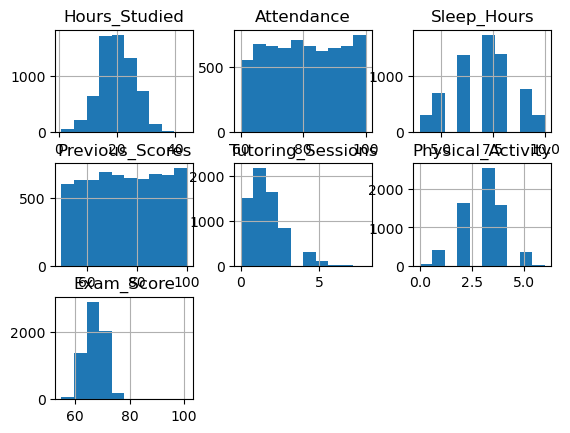

In [5]:
df.hist();

In [6]:
numeric_col = ['Hours_Studied', 'Attendence', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Session', 'Physical_Activity', 'Exam_Score']

In [7]:
non_numeric_col = []
for col in df.columns:
    if col not in numeric_col:
        non_numeric_col.append(col)

non_numeric_col

['Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender']

In [8]:
df.dropna()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [9]:
df.shape

(6607, 20)

In [10]:
high_attendence = df[df['Attendance'] > 95].copy()
high_attendence

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72
11,17,97,Medium,High,Yes,6,87,Low,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Male,71
21,19,99,Medium,High,No,6,84,Medium,Yes,1,Medium,High,Public,Neutral,3,No,High School,Near,Male,72
37,8,99,Medium,Medium,No,9,54,Low,Yes,2,Low,Medium,Public,Neutral,5,No,Postgraduate,Near,Female,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6555,12,100,Low,Medium,Yes,7,65,Medium,Yes,1,Low,Medium,Private,Positive,2,No,High School,Near,Male,67
6566,29,96,High,Medium,No,8,85,Low,Yes,3,High,Medium,Public,Neutral,3,No,Postgraduate,Near,Male,76
6580,18,100,Medium,Low,Yes,8,66,High,No,3,Low,Medium,Public,Negative,3,No,College,Near,Male,69
6592,29,100,Medium,Low,Yes,8,100,Low,Yes,0,Low,Medium,Private,Neutral,5,Yes,High School,Near,Male,72


In [11]:
df['Attendance'].agg(['max', 'min'])

max    100
min     60
Name: Attendance, dtype: int64

In [12]:
type(high_attendence)

pandas.core.frame.DataFrame

In [13]:
high_attendence.reset_index(drop=True, inplace=True)

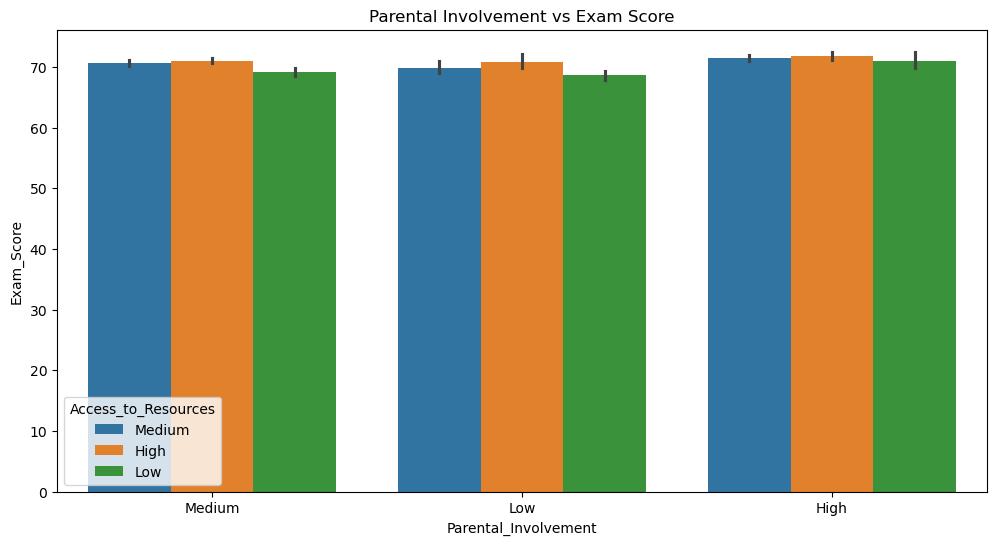

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(x='Parental_Involvement', y='Exam_Score', hue='Access_to_Resources', data=high_attendence)
plt.title('Parental Involvement vs Exam Score');

In [15]:
high_attendence.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
1,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72
2,17,97,Medium,High,Yes,6,87,Low,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Male,71
3,19,99,Medium,High,No,6,84,Medium,Yes,1,Medium,High,Public,Neutral,3,No,High School,Near,Male,72
4,8,99,Medium,Medium,No,9,54,Low,Yes,2,Low,Medium,Public,Neutral,5,No,Postgraduate,Near,Female,67


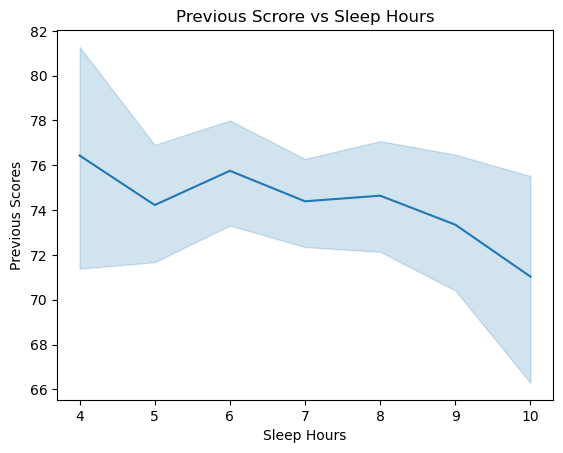

In [16]:
sns.lineplot(x='Sleep_Hours', y='Previous_Scores', data=high_attendence)
plt.ylabel('Previous Scores')
plt.xlabel('Sleep Hours')
plt.title('Previous Scrore vs Sleep Hours');

In [18]:
high_attendence['Extracurricular_Activities'].unique()

array(['Yes', 'No'], dtype=object)

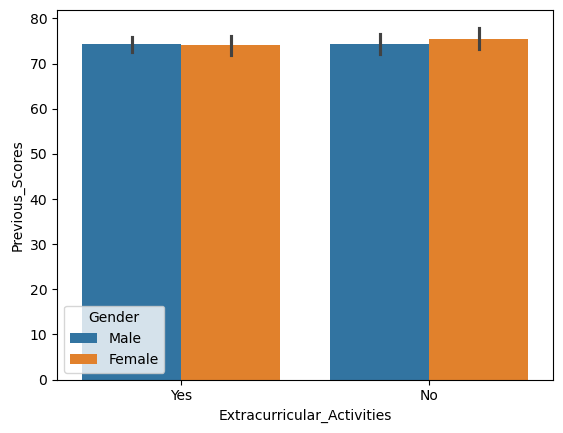

In [21]:
sns.barplot(x='Extracurricular_Activities', y='Previous_Scores', hue='Gender', data=high_attendence);

In [22]:
high_attendence['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [37]:
top_male_performers = high_attendence[high_attendence['Gender'] == 'Male'].copy()
top_female_performers = high_attendence[high_attendence['Gender'] == 'Female'].copy()

In [38]:
top_male_attendance

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
1,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72
2,17,97,Medium,High,Yes,6,87,Low,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Male,71
3,19,99,Medium,High,No,6,84,Medium,Yes,1,Medium,High,Public,Neutral,3,No,High School,Near,Male,72
5,11,98,Medium,Medium,Yes,9,82,Low,Yes,1,Medium,Medium,Private,Positive,3,No,Postgraduate,Far,Male,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,23,96,Medium,High,No,6,70,Medium,Yes,1,Medium,Medium,Public,Neutral,2,No,High School,Near,Male,71
746,12,100,Low,Medium,Yes,7,65,Medium,Yes,1,Low,Medium,Private,Positive,2,No,High School,Near,Male,67
747,29,96,High,Medium,No,8,85,Low,Yes,3,High,Medium,Public,Neutral,3,No,Postgraduate,Near,Male,76
748,18,100,Medium,Low,Yes,8,66,High,No,3,Low,Medium,Public,Negative,3,No,College,Near,Male,69


In [39]:
top_female_performers

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
4,8,99,Medium,Medium,No,9,54,Low,Yes,2,Low,Medium,Public,Neutral,5,No,Postgraduate,Near,Female,67
7,22,98,Medium,High,No,5,69,Low,No,1,Low,High,Public,Negative,4,No,High School,Moderate,Female,69
8,22,98,Medium,Low,Yes,7,52,Medium,No,3,Medium,Medium,Public,Positive,3,No,College,Near,Female,70
11,23,98,Medium,Low,Yes,7,54,Low,Yes,0,Medium,Medium,Public,Negative,3,No,College,Near,Female,68
17,35,99,High,High,Yes,7,85,Low,Yes,2,Medium,High,Private,Neutral,2,No,Postgraduate,Near,Female,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740,20,98,Low,High,Yes,8,67,Medium,Yes,0,High,Medium,Public,Positive,3,No,High School,Near,Female,71
743,29,97,Medium,High,Yes,9,92,Medium,Yes,2,Low,Medium,Public,Positive,4,No,High School,Moderate,Female,75
744,14,97,Medium,Medium,Yes,7,75,High,Yes,1,Medium,Medium,Public,Positive,4,No,College,Near,Female,70
745,18,98,High,Medium,Yes,6,62,Low,Yes,3,Medium,High,Public,Positive,3,No,High School,Far,Female,71


In [ ]:
high_attendence[high_attendence['Gender'] == 'Female']

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
4,8,99,Medium,Medium,No,9,54,Low,Yes,2,Low,Medium,Public,Neutral,5,No,Postgraduate,Near,Female,67
7,22,98,Medium,High,No,5,69,Low,No,1,Low,High,Public,Negative,4,No,High School,Moderate,Female,69
8,22,98,Medium,Low,Yes,7,52,Medium,No,3,Medium,Medium,Public,Positive,3,No,College,Near,Female,70
11,23,98,Medium,Low,Yes,7,54,Low,Yes,0,Medium,Medium,Public,Negative,3,No,College,Near,Female,68
17,35,99,High,High,Yes,7,85,Low,Yes,2,Medium,High,Private,Neutral,2,No,Postgraduate,Near,Female,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740,20,98,Low,High,Yes,8,67,Medium,Yes,0,High,Medium,Public,Positive,3,No,High School,Near,Female,71
743,29,97,Medium,High,Yes,9,92,Medium,Yes,2,Low,Medium,Public,Positive,4,No,High School,Moderate,Female,75
744,14,97,Medium,Medium,Yes,7,75,High,Yes,1,Medium,Medium,Public,Positive,4,No,College,Near,Female,70
745,18,98,High,Medium,Yes,6,62,Low,Yes,3,Medium,High,Public,Positive,3,No,High School,Far,Female,71


In [35]:
high_attendence.shape

(751, 20)